In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [5]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["target"].value_counts())

Dataset Shape: (150, 5)

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [7]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target:
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalized successfully.")

Features normalized successfully.


In [10]:
k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

for k, accuracy in zip(k_values, accuracies):
    print(f"K = {k}, Accuracy = {accuracy:.4f}")

K = 1, Accuracy = 0.9667
K = 2, Accuracy = 0.9333
K = 3, Accuracy = 0.9333
K = 4, Accuracy = 0.9333
K = 5, Accuracy = 0.9333
K = 6, Accuracy = 0.9333
K = 7, Accuracy = 0.9667
K = 8, Accuracy = 0.9333
K = 9, Accuracy = 0.9667
K = 10, Accuracy = 0.9667
K = 11, Accuracy = 0.9667
K = 12, Accuracy = 0.9667
K = 13, Accuracy = 0.9667
K = 14, Accuracy = 0.9667
K = 15, Accuracy = 0.9667


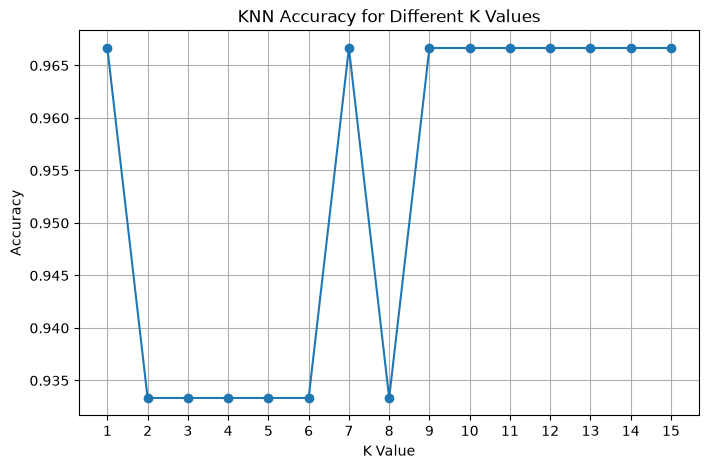

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.xticks(list(k_values))
plt.grid()

plt.savefig("knn_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

In [12]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)
print(f"Best Accuracy: {best_accuracy * 100:.2f}%")

Best K: 1
Best Accuracy: 0.9666666666666667
Best Accuracy: 96.67%


In [13]:
knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Final KNN model trained successfully.")

Final KNN model trained successfully.


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Accuracy: {accuracy:.2f}")
print(f"Final Model Accuracy: {accuracy * 100:.2f}%")

Final Model Accuracy: 0.97
Final Model Accuracy: 96.67%


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


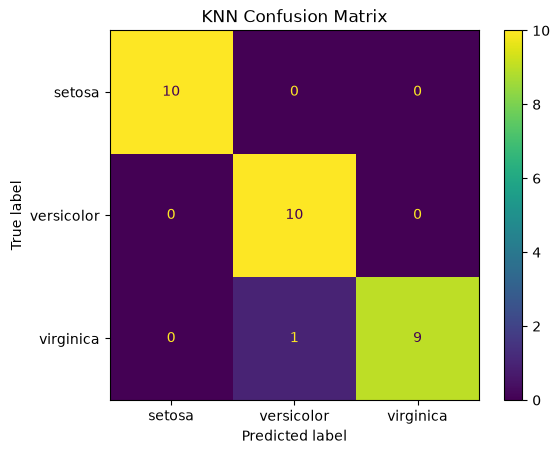

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()

plt.title("KNN Confusion Matrix")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

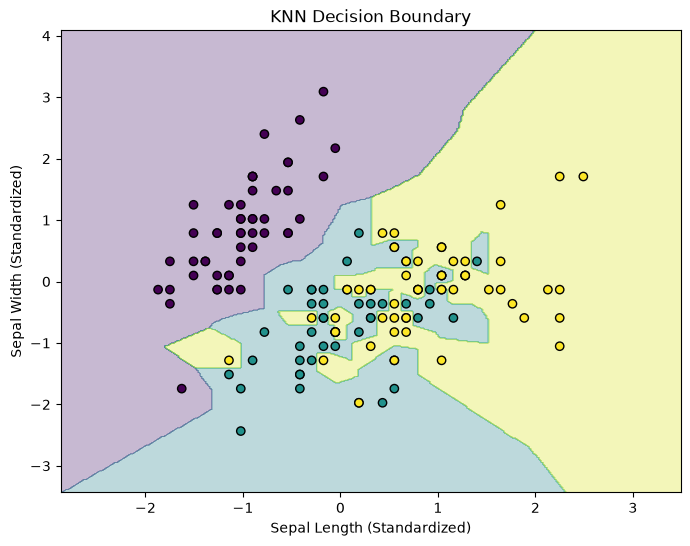

In [16]:
# Use two features for visualization
X_visual = iris.data[:, [0, 1]]
y_visual = iris.target

# Normalize features
scaler_visual = StandardScaler()
X_visual_scaled = scaler_visual.fit_transform(X_visual)

# Train KNN
knn_visual = KNeighborsClassifier(n_neighbors=best_k)
knn_visual.fit(X_visual_scaled, y_visual)

# Create mesh
x_min, x_max = X_visual_scaled[:, 0].min() - 1, X_visual_scaled[:, 0].max() + 1
y_min, y_max = X_visual_scaled[:, 1].min() - 1, X_visual_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict
Z = knn_visual.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_visual_scaled[:, 0],
    X_visual_scaled[:, 1],
    c=y_visual,
    edgecolor="k"
)

plt.xlabel("Sepal Length (Standardized)")
plt.ylabel("Sepal Width (Standardized)")
plt.title("KNN Decision Boundary")

plt.savefig(
    "decision_boundary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
